X =
 [[1. 2.]
 [2. 1.]
 [3. 0.]
 [4. 3.]
 [5. 4.]]
y =
 [13. 12. 11. 22. 27.]
Iteration 0, Loss = 329.4000
Iteration 100, Loss = 1.5835
Iteration 200, Loss = 0.7993
Iteration 300, Loss = 0.4059
Iteration 400, Loss = 0.2062
Iteration 500, Loss = 0.1048
Iteration 600, Loss = 0.0532
Iteration 700, Loss = 0.0270
Iteration 800, Loss = 0.0137
Iteration 900, Loss = 0.0070

Final Parameters:
m1 = 2.0381867684358346
m2 = 3.000765000469794
b  = 4.86029727914751


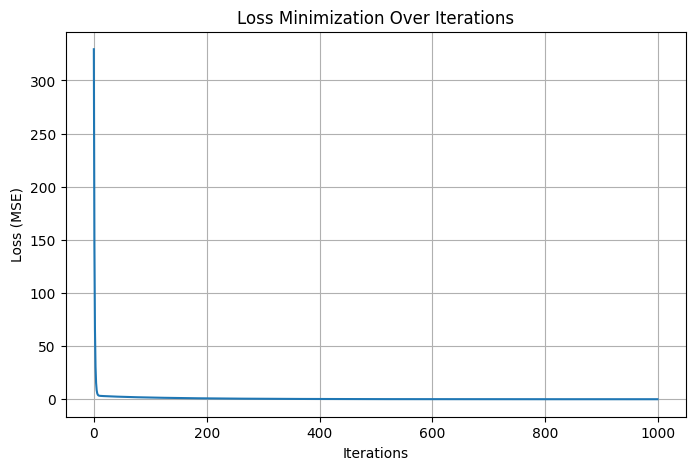

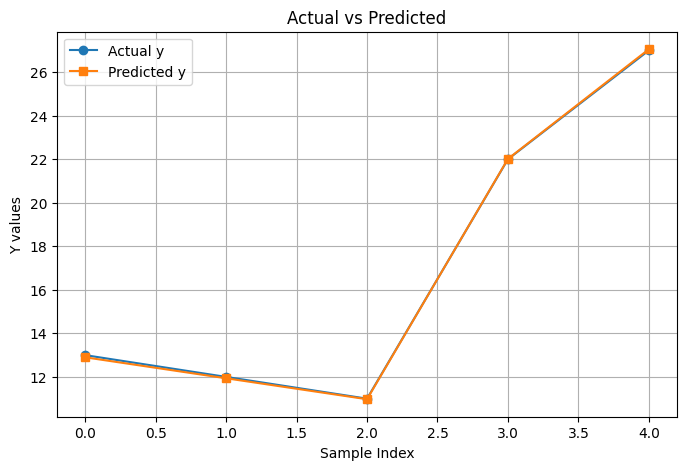

Prediction for x1 = 3.0, x2 = 5.0 is: 25.978682586803984


In [2]:
# =========================================
# Multiple Linear Regression (from Scratch)
# For x1, x2 -> y
# =========================================
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Step 1: Model Hypothesis (Prediction)
# y_hat = m1*x1 + m2*x2 + b
# -----------------------------------------
def predict(X, m, b):
    return np.dot(X, m) + b


# -----------------------------------------
# Step 2: Cost Function (Mean Squared Error)
# -----------------------------------------
def compute_cost(y, y_hat):
    n = len(y)
    return (1 / n) * np.sum((y - y_hat) ** 2)


# -----------------------------------------
# Step 3: Partial Derivatives
# dm = (-2/n) * X^T * (y - y_hat)
# db = (-2/n) * sum(y - y_hat)
# -----------------------------------------
def compute_gradients(X, y, y_hat):
    n = len(y)
    error = y - y_hat

    dm = (-2 / n) * np.dot(X.T, error)   # gradient for m1 and m2
    db = (-2 / n) * np.sum(error)        # gradient for b

    return dm, db


# -----------------------------------------
# Step 4: Update Parameters
# -----------------------------------------
def update_parameters(m, b, dm, db, alpha):
    m = m - alpha * dm
    b = b - alpha * db
    return m, b


# -----------------------------------------
# Step 5: Initialize Parameters
# -----------------------------------------
def initialize_parameters(n_features):
    m = np.zeros(n_features)
    b = 0.0
    return m, b


# -----------------------------------------
# Step 6: Model Training
# -----------------------------------------
def train(X, y, alpha=0.01, iterations=1000):
    n_features = X.shape[1]
    m, b = initialize_parameters(n_features)
    loss_history = []

    for i in range(iterations):
        # Prediction
        y_hat = predict(X, m, b)

        # Cost
        loss = compute_cost(y, y_hat)
        loss_history.append(loss)

        # Gradients
        dm, db = compute_gradients(X, y, y_hat)

        # Update
        m, b = update_parameters(m, b, dm, db, alpha)

        if i % 100 == 0:
            print(f"Iteration {i}, Loss = {loss:.4f}")

    return m, b, loss_history


# -----------------------------------------
# Step 7: Dataset Loading
# Example dataset satisfying:
# y = 2*x1 + 3*x2 + 5
# -----------------------------------------
x1 = np.array([1, 2, 3, 4, 5], dtype=float)
x2 = np.array([2, 1, 0, 3, 4], dtype=float)
y  = np.array([13, 12, 11, 22, 27], dtype=float)

# Combine x1 and x2 into feature matrix X
X = np.column_stack((x1, x2))

print("X =\n", X)
print("y =\n", y)


# -----------------------------------------
# Step 8: Train Model
# -----------------------------------------
m, b, loss_history = train(X, y, alpha=0.01, iterations=1000)

print("\nFinal Parameters:")
print("m1 =", m[0])
print("m2 =", m[1])
print("b  =", b)


# -----------------------------------------
# Step 9: Plot Loss Minimization
# -----------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss Minimization Over Iterations")
plt.grid(True)
plt.show()


# -----------------------------------------
# Step 10: Actual vs Predicted Values
# -----------------------------------------
y_pred = predict(X, m, b)

plt.figure(figsize=(8, 5))
plt.plot(y, marker='o', label="Actual y")
plt.plot(y_pred, marker='s', label="Predicted y")
plt.xlabel("Sample Index")
plt.ylabel("Y values")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


# -----------------------------------------
# Step 11: Predict New Value
# -----------------------------------------
x1_new = float(input("Enter x1 value: "))
x2_new = float(input("Enter x2 value: "))

X_new = np.array([[x1_new, x2_new]])
y_new_pred = predict(X_new, m, b)

print(f"Prediction for x1 = {x1_new}, x2 = {x2_new} is: {y_new_pred[0]}")

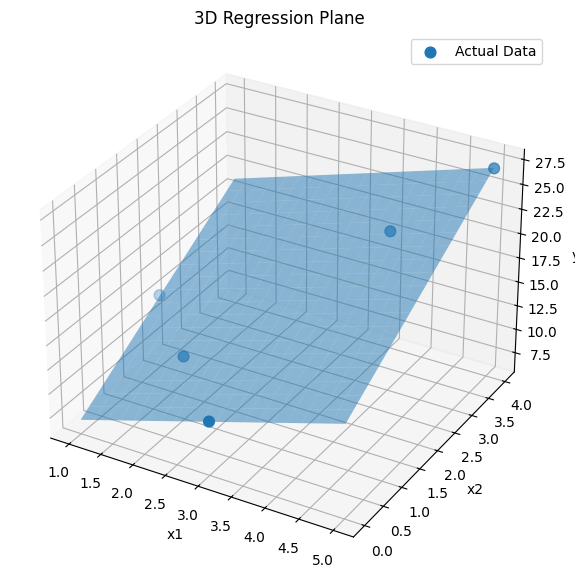

In [3]:
# Assume m and b are already learned from your scratch code
# m[0] = m1, m[1] = m2

x1_range = np.linspace(x1.min(), x1.max(), 20)
x2_range = np.linspace(x2.min(), x2.max(), 20)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)

y_grid = m[0] * x1_grid + m[1] * x2_grid + b

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y, s=60, label='Actual Data')
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5)

ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D Regression Plane')

plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Dataset
x1 = np.array([1, 2, 3, 4, 5], dtype=float)
x2 = np.array([2, 1, 0, 3, 4], dtype=float)
y  = np.array([13, 12, 11, 22, 27], dtype=float)

X = np.column_stack((x1, x2))

# Model
model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)   # [m1, m2]

# Predict new value
x1_new = float(input("Enter x1 value: "))
x2_new = float(input("Enter x2 value: "))

pred = model.predict(np.array([[x1_new, x2_new]]))
print(f"Prediction for x1 = {x1_new}, x2 = {x2_new} is: {pred[0]}")

Intercept: 5.0000000000000036
Coefficients: [2. 3.]
